In [1]:
#IMPORTS
%matplotlib widget
import re
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.signal import hilbert
from scipy.optimize import curve_fit
import ipywidgets as widgets

In [2]:
#NAMING SETUP

base_dir = Path("metingen")

position_names = [f"0-{i}" for i in range(1, 5)] + [f"{i}-4" for i in range(1, 5)]

def numbered_names(prefix, count):
    return [prefix] + [f"{prefix} ({i})" for i in range(1, count)]

raw_source_names = numbered_names("usr_wf_C1_data", 3) #3 raw replicate files
fft_source_names = numbered_names("usr_wf_F1_data", 3) #3 fft replicate files

In [3]:
#LENGTHS

length_pattern = re.compile(r"(\d+(?:\.\d+)?)\s*cm")

def parse_length(folder_name):
    match = length_pattern.search(folder_name)
    if match:
        return float(match.group(1))
    return None

In [4]:
#FORCES

g = 9.81 #m/s
notch_to_ratio = {0: 0, 1: 4, 2: 6, 3: 8, 4: 10} #notch to lever ratio
gewicht_1 = 1.0468 #kg
gewicht_2 = 1.0436 #kg

def position_force(position):
    w2_notch, w1_notch = (int(n) for n in position.split("-"))
    return gewicht_1*g*notch_to_ratio[w1_notch]+gewicht_2*g*notch_to_ratio[w2_notch]

forces_arr = np.array([position_force(p) for p in position_names], dtype=float)

In [5]:
#FOLDER NAMES AND LENGTHS

cm_folders = sorted(f for f in base_dir.iterdir() if f.is_dir() and "23" not in f.name)

length_names_sorted = [f.name for f in cm_folders]
lengths_arr = np.array([parse_length(name) for name in length_names_sorted])

In [6]:
#GET SHAPE

def find_shape(source_names):
    for cm_folder in cm_folders:
        for position in position_names:
            position_folder = cm_folder / f"metingen {position}"
            for source_name in source_names:
                file_path = position_folder / f"{source_name}.csv"
                if file_path.exists():
                    return np.loadtxt(file_path, skiprows=12, delimiter=",").shape

raw_shape = find_shape(raw_source_names)
fft_shape = find_shape(fft_source_names)

In [7]:
#PREALLOCATE FINAL ARRAYS

n_lengths = len(cm_folders)
n_positions = len(position_names)
n_replicates = 3

raw_array = np.full((n_lengths, n_positions, n_replicates, *raw_shape), np.nan)
fft_array = np.full((n_lengths, n_positions, n_replicates, *fft_shape), np.nan)

In [8]:
#LOAD FILES INTO ARRAY SLOTS

for i, cm_folder in enumerate(cm_folders):
    print(f"Processing folder: {cm_folder.name}")
    for j, position in enumerate(position_names):
        position_folder = cm_folder / f"metingen {position}"
        for r, source_name in enumerate(raw_source_names, start=1):
            file_path = position_folder / f"{source_name}.csv"
            if file_path.exists():
                raw_array[i, j, r-1] = np.loadtxt(file_path, skiprows=12, delimiter=",")
        for r, source_name in enumerate(fft_source_names, start=1):
            file_path = position_folder / f"{source_name}.csv"
            if file_path.exists():
                fft_array[i, j, r-1] = np.loadtxt(file_path, skiprows=12, delimiter=",")

print("raw_array shape:", raw_array.shape)
print("fft_array shape:", fft_array.shape)

Processing folder: metingen 25.5 cm
Processing folder: metingen 27 cm
Processing folder: metingen 28.5 cm
Processing folder: metingen 30 cm
Processing folder: metingen 31.5 cm
raw_array shape: (5, 8, 3, 10000, 2)
fft_array shape: (5, 8, 3, 4096, 5)


In [9]:
#METADATA GRIDS

length_grid = np.broadcast_to(lengths_arr[:, None], (n_lengths, n_positions))*10**-2
force_grid = np.broadcast_to(forces_arr[None, :], (n_lengths, n_positions))

In [10]:
#TRIMMING DATA

def manual_trim(margin):
    n_lengths, n_positions, n_replicates, n_samples_raw, n_cols_raw = raw_array.shape
    start_indices = np.zeros((n_lengths, n_positions, n_replicates), dtype=int)

    for i in range(n_lengths):
        for j in range(n_positions):
            for r in range(n_replicates):
                start_indices[i, j, r] = margin

    #every signal keeps the same number of points after its own start, so the result stays rectangular
    trimmed_length = n_samples_raw - start_indices.max()
    raw_trimmed = np.full((n_lengths, n_positions, n_replicates, trimmed_length, n_cols_raw), np.nan)

    for i in range(n_lengths):
        for j in range(n_positions):
            for r in range(n_replicates):
                start = start_indices[i, j, r]
                if start >= n_samples_raw:
                    continue
                raw_trimmed[i, j, r] = raw_array[i, j, r, start:start + trimmed_length, :]

    return raw_trimmed, trimmed_length

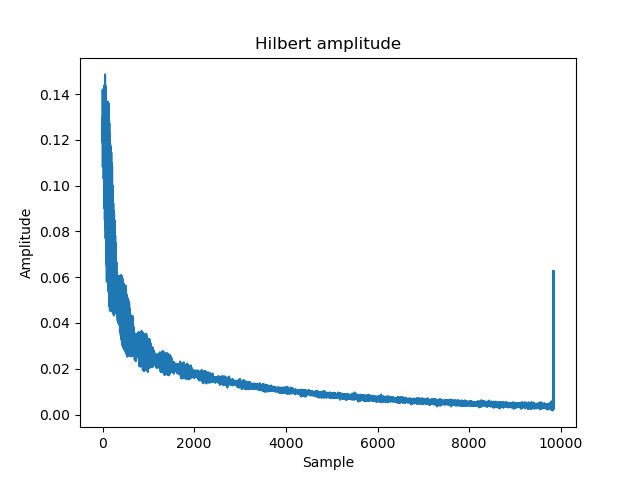

In [11]:
raw_trim , trim_L = manual_trim(160)

b = hilbert(raw_trim)
i = 0   # eerste lengte
j = 0   # eerste positie
r = 0   # eerste replicaat
col = 1 # kolom met het signaal

signal = raw_trim[i, j, r, :, col]
analytic = hilbert(signal)
amplitude = np.abs(analytic)

plt.plot(amplitude)
plt.title("Hilbert amplitude")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

In [12]:
C_w = 1.2
rho = 1.204
D = 0.001
mu = ((D/2)**2)*np.pi*7900
n = 1
U_0 = 0.5

m1 = 1.0467
m2 = 1.0436
g = 9.81

T1 = g*4*m1
T2 = g*6*m1
T3 = g*8*m1
T4 = g*10*m1
T5 = T4 + g*4*m2
T6 = T4 + g*6*m2
T7 = T4 + g*8*m2
T8 = T4 + g*10*m2

T_array = np.array([T1, T2, T3, T4, T5, T6, T7, T8])

def alpha_theory(L, T):
    return (2*C_w*rho*D*n/(3*mu*L**2))*np.sqrt(T/mu)

def theory_amp(t, alpha, U0=U_0):
    return U0 / (alpha*U0*t + 1)

# -----------------------------
# Kies één meting
# -----------------------------
i = 0       # lengte-index
j = 0       # positie-index (T1)
r = 0       # replicaat
col = 1     # signaalkolom

signal = raw_trim[i, j, r, :, col]
analytic = hilbert(signal)
envelope = np.abs(analytic)
trim = 30   # aantal punten om weg te gooien aan het einde

t_trim = t[:-trim]
envelope_trim = envelope[:-trim]
fs = 20000   # voorbeeld sampling freq
t = np.arange(len(envelope)) / fs

L = length_grid[i, j]
T = T_array[j]

alpha_th = alpha_theory(L, T)

from scipy.optimize import curve_fit
popt, pcov = curve_fit(theory_amp, t, envelope, p0=[alpha_th])
alpha_fit = popt[0]

plt.figure()

plt.plot(t_trim, envelope_trim, label="Hilbert amplitude")
plt.plot(t_trim, theory_amp(t_trim, alpha_fit), label="fit")
plt.plot(t_trim, theory_amp(t_trim, alpha_th), "--", label="theorie")
plt.legend()
plt.show()


NameError: name 't' is not defined

T=41.1 N: alpha_theory = 194, alpha_fit = 664
T=61.6 N: alpha_theory = 238, alpha_fit = 273
T=82.1 N: alpha_theory = 275, alpha_fit = 397
T=102.7 N: alpha_theory = 307, alpha_fit = 574
T=143.6 N: alpha_theory = 363, alpha_fit = 354
T=164.1 N: alpha_theory = 388, alpha_fit = 323
T=184.6 N: alpha_theory = 412, alpha_fit = 237
T=205.1 N: alpha_theory = 434, alpha_fit = 187


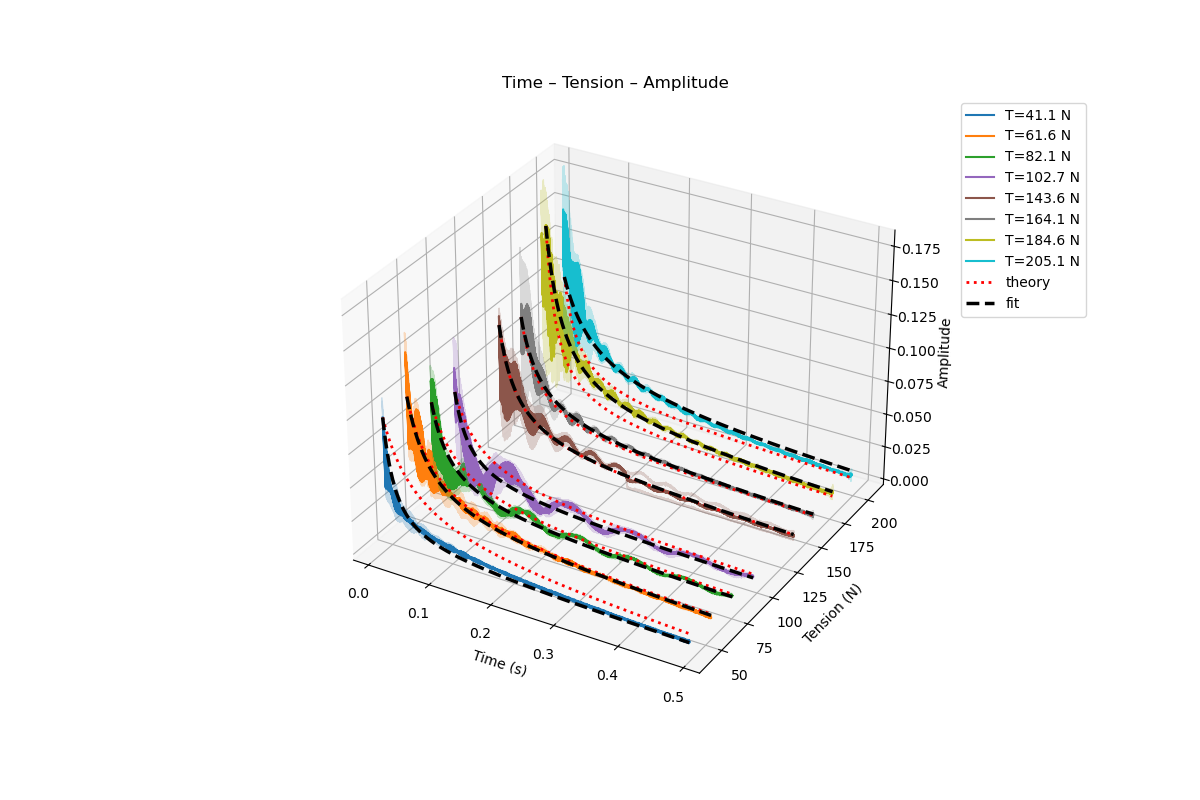

L=0.255 m: alpha_theory = 194, alpha_fit = 664
L=0.270 m: alpha_theory = 173, alpha_fit = 430
L=0.285 m: alpha_theory = 155, alpha_fit = 484
L=0.300 m: alpha_theory = 140, alpha_fit = 353
L=0.315 m: alpha_theory = 127, alpha_fit = 332


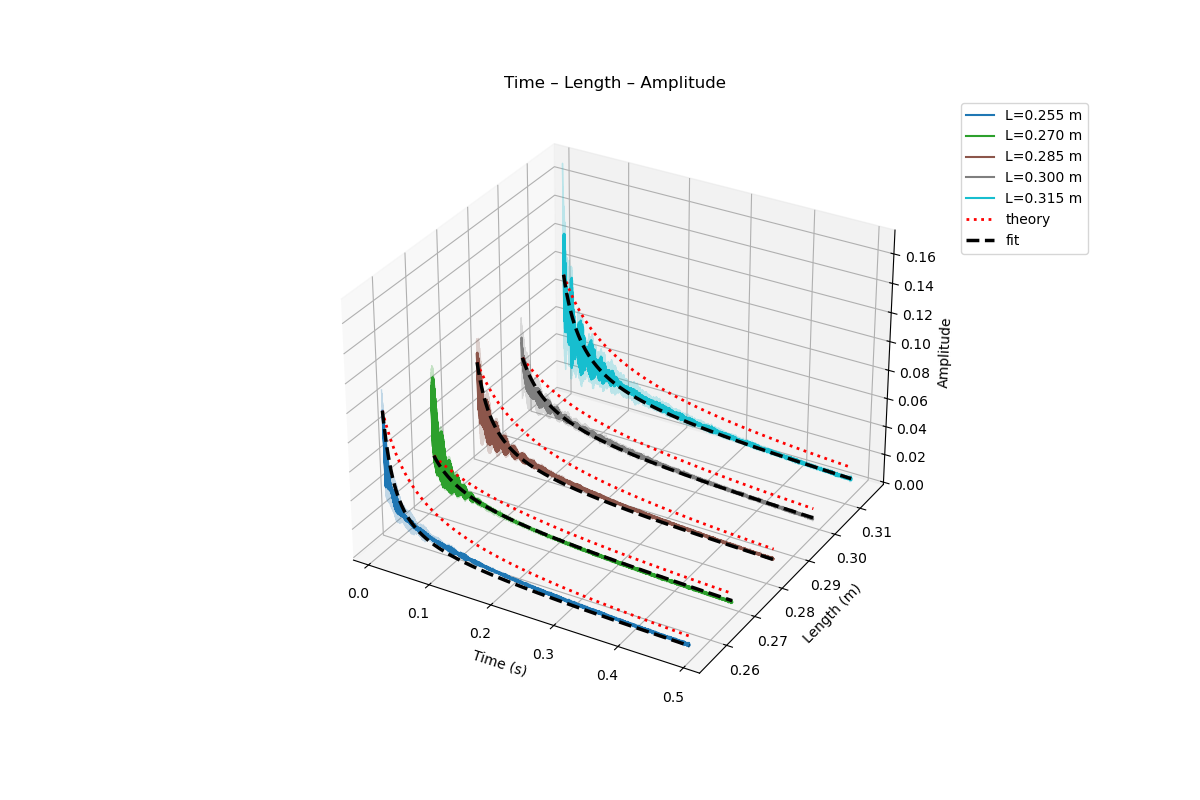

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
from scipy.ndimage import uniform_filter1d
from scipy.optimize import curve_fit
from scipy.signal import hilbert

fs = 20000
start_trim = 200     # samples removed at start (Hilbert edge effect)
end_trim = 50        # samples removed at end
peak_window = 4000   # first peak is searched within this many samples after start_trim
smooth_n = 51        # smoothing width used only to locate the peak


def get_envelope(i, j):
    """Mean/std Hilbert envelope over replicates (skips replicates with NaNs)."""
    envs = []
    for r in range(n_replicates):
        sig = raw_trim[i, j, r, :, 1]
        if np.all(np.isfinite(sig)):
            envs.append(np.abs(hilbert(sig)))
    if not envs:
        return None
    envs = np.array(envs)
    t = np.arange(envs.shape[1]) / fs
    sl = slice(start_trim, -end_trim)
    return t[sl], envs.mean(axis=0)[sl], envs.std(axis=0)[sl]


def analyse(i, j):
    out = get_envelope(i, j)
    if out is None:
        return None
    t, mean, std = out

    # first peak of the envelope
    k = int(np.argmax(uniform_filter1d(mean, smooth_n, mode="nearest")[:peak_window]))
    U0 = mean[k]
    t_rel = t[k:] - t[k]          # time since the peak

    alpha_th = alpha_theory(length_grid[i, j], T_array[j])

    # fit only alpha; U0 is fixed to the peak so fit and theory start on the data
    try:
        popt, _ = curve_fit(lambda tt, a: theory_amp(tt, a, U0),
                            t_rel, mean[k:], p0=[alpha_th], bounds=(0, np.inf))
        alpha_fit = popt[0]
    except RuntimeError:
        alpha_fit = np.nan

    return dict(t=t, mean=mean, std=std, k=k, U0=U0, t_rel=t_rel,
                alpha_th=alpha_th, alpha_fit=alpha_fit)


def plot_3d(pairs, y_vals, ylabel, labels, title):
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d", computed_zorder=False)
    colors = plt.cm.tab10(np.linspace(0, 1, len(pairs)))

    for col, (i, j), y, lab in zip(colors, pairs, y_vals, labels):
        res = analyse(i, j)
        if res is None:
            continue
        t, mean, std, k = res["t"], res["mean"], res["std"], res["k"]

        # data + std band (bottom layer)
        y_line = np.full_like(t, y)
        ax.plot(t, y_line, mean, color=col, lw=1.5, zorder=1, label=lab)
        ax.plot(t, y_line, mean + std, color=col, alpha=0.25, lw=1, zorder=1)
        ax.plot(t, y_line, mean - std, color=col, alpha=0.25, lw=1, zorder=1)

        # theory + fit, both starting on the first peak
        t_pk = t[k:]
        y_pk = np.full_like(t_pk, y)
        ax.plot(t_pk, y_pk, theory_amp(res["t_rel"], res["alpha_th"], res["U0"]),
                color="red", ls=":", lw=2, zorder=2)
        if np.isfinite(res["alpha_fit"]):
            ax.plot(t_pk, y_pk, theory_amp(res["t_rel"], res["alpha_fit"], res["U0"]),
                    color="black", ls="--", lw=2.5, zorder=3)   # drawn on top

        print(f"{lab}: alpha_theory = {res['alpha_th']:.3g}, alpha_fit = {res['alpha_fit']:.3g}")

    handles, _ = ax.get_legend_handles_labels()
    handles += [Line2D([0], [0], color="red", ls=":", lw=2),
                Line2D([0], [0], color="black", ls="--", lw=2.5)]
    names = [h.get_label() for h in handles[:-2]] + ["theory", "fit"]
    ax.legend(handles, names, loc="upper left", bbox_to_anchor=(1.05, 1))

    ax.set_xlabel("Time (s)")
    ax.set_ylabel(ylabel)
    ax.set_zlabel("Amplitude")
    ax.set_title(title)
    plt.show()


# 3D plot 1: time - tension - amplitude (fixed length)
i0 = 0
plot_3d(pairs=[(i0, j) for j in range(n_positions)],
        y_vals=T_array,
        ylabel="Tension (N)",
        labels=[f"T={T:.1f} N" for T in T_array],
        title="Time – Tension – Amplitude")

# 3D plot 2: time - length - amplitude (fixed tension)
j0 = 0
plot_3d(pairs=[(i, j0) for i in range(n_lengths)],
        y_vals=length_grid[:, j0],
        ylabel="Length (m)",
        labels=[f"L={length_grid[i, j0]:.3f} m" for i in range(n_lengths)],
        title="Time – Length – Amplitude")